In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# Set seaborn style 
sns.set_theme(style="whitegrid")

In [16]:
# 1. Dataset Loading & MNAR Simulation

data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target
target_names = ['Malignant (0)', 'Benign (1)']


In [18]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [32]:
# Simulate MNAR: Malignant (0) mein 60% missing, Benign (1) mein 5% missing
np.random.seed(42)
X_mnar = X.copy()
missing_mask_malignant = (y == 0) & (np.random.rand(len(y)) < 0.60)
missing_mask_benign = (y == 1) & (np.random.rand(len(y)) < 0.05)
X_mnar.loc[missing_mask_malignant | missing_mask_benign, 'mean area'] = np.nan


In [35]:
X_mnar.sample(5)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
282,19.40,18.18,127.20,NaN,0.10370,0.14420,0.16260,0.09464,0.1893,0.05892,...,23.79,28.65,152.40,1628.0,0.1518,0.3749,0.4316,0.22520,0.3590,0.07787
479,16.25,19.51,109.80,NaN,0.10260,0.18930,0.22360,0.09194,0.2151,0.06578,...,17.39,23.05,122.10,939.7,0.1377,0.4462,0.5897,0.17750,0.3318,0.09136
513,14.58,13.66,94.29,658.8,0.09832,0.08918,0.08222,0.04349,0.1739,0.05640,...,16.76,17.24,108.50,862.0,0.1223,0.1928,0.2492,0.09186,0.2626,0.07048
488,11.68,16.17,75.49,420.5,0.11280,0.09263,0.04279,0.03132,0.1853,0.06401,...,13.32,21.59,86.57,549.8,0.1526,0.1477,0.1490,0.09815,0.2804,0.08024
507,11.06,17.12,71.25,366.5,0.11940,0.10710,0.04063,0.04268,0.1954,0.07976,...,11.69,20.74,76.08,411.1,0.1662,0.2031,0.1256,0.09514,0.2780,0.11680


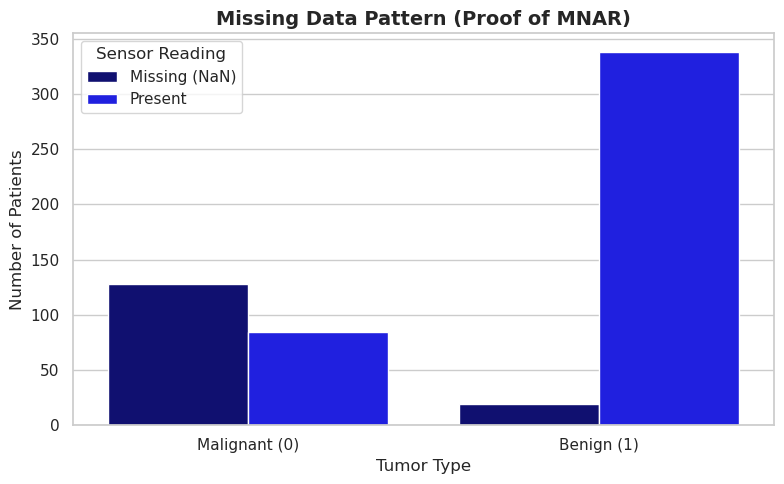

In [31]:
# Proof of MNAR (The Problem)

# Data prepare kar rahe hain plotting ke liye
plot_df = pd.DataFrame({
    'Target': [target_names[val] for val in y],
    'Mean Area Status': np.where(X_mnar['mean area'].isna(), 'Missing (NaN)', 'Present')
})

plt.figure(figsize=(8, 5))
sns.countplot(data=plot_df, x='Target', hue='Mean Area Status', palette=['navy', 'blue'])
plt.title('Missing Data Pattern (Proof of MNAR)', fontsize=14, fontweight='bold')
plt.ylabel('Number of Patients')
plt.xlabel('Tumor Type')
plt.legend(title='Sensor Reading')
plt.tight_layout()
plt.show()


In [9]:
# ML Pipeline Setup & Training

X_train, X_test, y_train, y_test = train_test_split(X_mnar, y, test_size=0.2, random_state=42)

# Imputer with Indicator!
imputer_with_indicator = SimpleImputer(strategy='median', add_indicator=True)

preprocessor = ColumnTransformer(
    transformers=[('impute', imputer_with_indicator, ['mean area'])],
    remainder='passthrough',
    force_int_remainder_cols=False
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])


In [10]:
# Train the model
pipeline.fit(X_train, y_train)



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('impute',
                                                  SimpleImputer(add_indicator=True,
                                                                strategy='median'),
                                                  ['mean area'])])),
                ('classifier',
                 RandomForestClassifier(n_jobs=-1, random_state=42))])

In [11]:
# Feature Importance (The Solution)

# Extracting feature names properly

# Scikit-learn prepends the transformer name, so we clean it up for the graph
raw_feature_names = preprocessor.get_feature_names_out()
clean_feature_names = [name.split('__')[-1] for name in raw_feature_names]

# Rename the indicator column so it looks professional in the graph
clean_feature_names = ['Indicator: Was Mean Area Missing?' if 'missingindicator' in name else name for name in clean_feature_names]

# Extract importances from Random Forest
importances = pipeline.named_steps['classifier'].feature_importances_


In [12]:
importances

array([0.01005508, 0.01648728, 0.03698604, 0.01373215, 0.05077149,
       0.00597265, 0.01660898, 0.05219343, 0.08810001, 0.0039802 ,
       0.00585119, 0.01796416, 0.00334582, 0.01988165, 0.03492171,
       0.00376124, 0.00476661, 0.00985344, 0.00465219, 0.00500149,
       0.00593085, 0.10624542, 0.01180633, 0.13553033, 0.12759238,
       0.01303343, 0.01732554, 0.05431388, 0.10645482, 0.01263083,
       0.00424938])

In [13]:
clean_feature_names

['mean area',
 'Indicator: Was Mean Area Missing?',
 'mean radius',
 'mean texture',
 'mean perimeter',
 'mean smoothness',
 'mean compactness',
 'mean concavity',
 'mean concave points',
 'mean symmetry',
 'mean fractal dimension',
 'radius error',
 'texture error',
 'perimeter error',
 'area error',
 'smoothness error',
 'compactness error',
 'concavity error',
 'concave points error',
 'symmetry error',
 'fractal dimension error',
 'worst radius',
 'worst texture',
 'worst perimeter',
 'worst area',
 'worst smoothness',
 'worst compactness',
 'worst concavity',
 'worst concave points',
 'worst symmetry',
 'worst fractal dimension']

In [19]:
# Create a DataFrame for plotting
importance_df = pd.DataFrame({
    'Feature': clean_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


In [20]:
importance_df

,Feature,Importance
23,worst perimeter,0.135530
24,worst area,0.127592
28,worst concave points,0.106455
21,worst radius,0.106245
8,mean concave points,0.088100
27,worst concavity,0.054314
7,mean concavity,0.052193
4,mean perimeter,0.050771
2,mean radius,0.036986
14,area error,0.034922


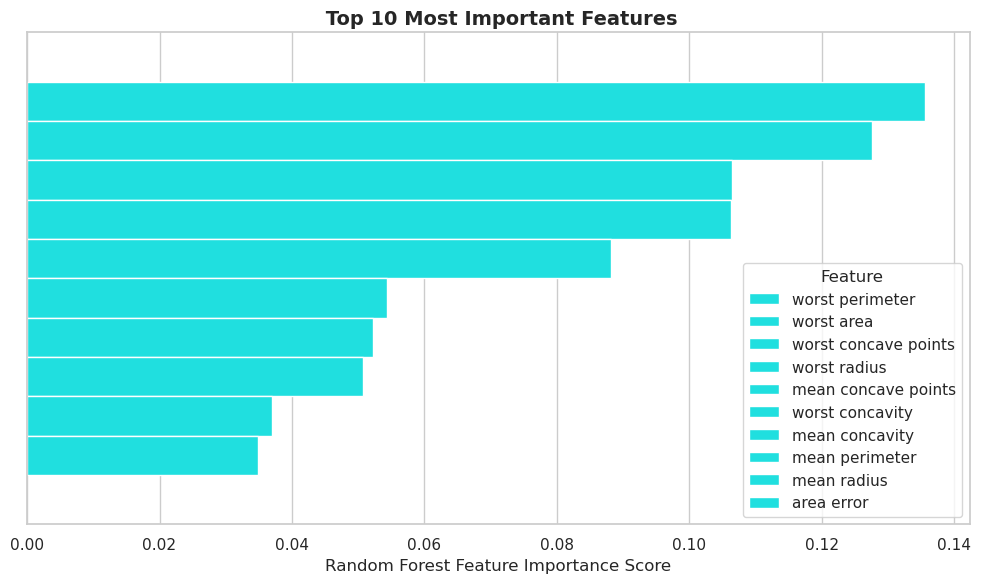

In [26]:
# Plotting Top 10 Features
plt.figure(figsize=(10, 6))
# Highlight the 'Indicator' feature with a distinct color (Red), others Blue
colors = ['purple' if 'Indicator' in feat else 'aqua' for feat in importance_df['Feature'].head(10)]

sns.barplot(data=importance_df.head(10), x='Importance', hue='Feature', palette=colors)
plt.title(' Top 10 Most Important Features', fontsize=14, fontweight='bold')
plt.xlabel('Random Forest Feature Importance Score')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [1]:
import datetime
today = datetime.date.today()
print(f"Today's data: {today}")

Today's data: 2026-03-28
